## Classical ML Model #1: **Binomial Logistic Regression**


First, we will import our pre-split and scaled training, validation, and test sets.

In [13]:
import pandas as pd
import numpy as np
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training

### **Training Set**: Binomial Logistic Regression

We are trying to predict if the our target class URB is rural or urban, 2 classes so a Binomial Logistic Regression is a natural pick. Let's first create our model using the the import from the sklearn library for our logistic Regression

In [14]:
# Logistic Regression (L2 Regularization) - Training Phase
from sklearn.linear_model import LogisticRegression

# Regularized logistic regression model
logreg_model = LogisticRegression(
    penalty="l2",       # regularization type (this is default)
    C=1.0,               # regularization strength (also a default)
    solver="lbfgs",     # optimizer (good default for larger datasets)
    max_iter=100,
    random_state=42
)

logreg_model.fit(X_train_scaled, y_train)

# Training-set predictions and probabilities
y_train_pred = logreg_model.predict(X_train_scaled)
y_train_proba = logreg_model.predict_proba(X_train_scaled)[:, 1]

c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


With our training split, we currently have **28119** rows. We will use **44** features to predict target feature `URB` whether its rural or urban. But why 88 features? We performed one-hot-encoding on 7 of our used features. `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Furthurmore, we remove the target column `URB`.

In [15]:
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Training features used: {X_train_scaled.shape[1]}")

Training samples: 28119
Training features used: 81


Let's now output our metrics. It is important to note that our classes are imbalanced. The entire dataset contains 40171 total number of entries. There are 15373 urban families and 24798 rural families.

In [16]:
from MCO_functions import report_binary_metrics, build_metric_series, highlight_val_train_row, run_logreg_validation_grid

train_report = report_binary_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    y_proba=y_train_proba,
    title="Training Metrics",
    n_iter=logreg_model.n_iter_,
)

cm_train = train_report["cm"]
cm_train_df = train_report["cm_df"]
rural_acc_train = train_report["rural_acc"]
urban_acc_train = train_report["urban_acc"]

Training Metrics (Overall)
Accuracy        : 0.8231
Balanced Acc    : 0.7989
ROC-AUC         : 0.8869
PR-AUC          : 0.8606
Log Loss        : 0.3938

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.9022,0.6956
Precision,0.8270,0.8151
Recall,0.9022,0.6956
F1-score,0.8630,0.7506



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)           15660            1698
Actual Urban (1)            3276            7485

Iterations used: [100]


Our model used 96 iterations in the training set, lets visualize a graph of its loss to see how it improves

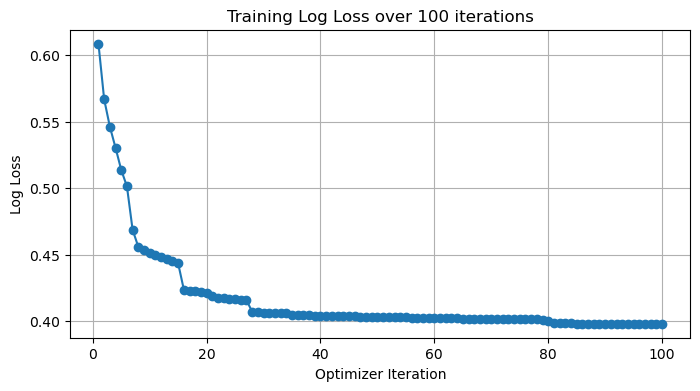

Showing first 10 and last 10 iterations out of 100 total:


,Optimizer Iteration,Train Log Loss
0,1,0.608533
1,2,0.566816
2,3,0.546270
3,4,0.530360
4,5,0.513741
5,6,0.501368
6,7,0.468699
7,8,0.455949
8,9,0.453327
9,10,0.451354


In [17]:
# Optional: inspect training loss over all optimizer iterations (reusable helper)
from MCO_functions import track_logreg_loss_by_iteration

# Track the same number of iterations used by the fitted training model
total_iters = int(np.ravel(logreg_model.n_iter_)[0])

loss_tracking = track_logreg_loss_by_iteration(
    X_train=X_train_scaled,
    y_train=y_train,
    total_iterations=total_iters,
    c=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight=None,
    random_state=42,
    head_n=10,
    tail_n=10,
    plot=True,
)

loss_history_df = loss_tracking["full_loss_df"]
loss_window_df = loss_tracking["compact_loss_df"]

print(f"Showing first 10 and last 10 iterations out of {total_iters} total:")
display(loss_window_df.style.format({"Train Log Loss": "{:.6f}"}))

# **[5]** Error Analysis and Model Tuning


### **Validation Set** (Pre-Tuned): Binomial Logistic Regression

Using our trained model, let's test it on the validation set. The validation set has **6026** rows of data

In [18]:
from MCO_functions import report_binary_metrics

# BEFORE TUNING: baseline validation metrics
y_val_pred = logreg_model.predict(X_val_scaled)
y_val_proba = logreg_model.predict_proba(X_val_scaled)[:, 1]

val_base_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    title="Current Validation Metrics (Before Tuning)",
)

cm_base = val_base_report["cm"]
cm_base_df = val_base_report["cm_df"]
rural_acc_base = val_base_report["rural_acc"]
urban_acc_base = val_base_report["urban_acc"]

Current Validation Metrics (Before Tuning) (Overall)
Accuracy        : 0.8070
Balanced Acc    : 0.7843
ROC-AUC         : 0.8765
PR-AUC          : 0.8464
Log Loss        : 0.4109

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8809,0.6878
Precision,0.8199,0.7817
Recall,0.8809,0.6878
F1-score,0.8493,0.7317



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3277             443
Actual Urban (1)             720            1586


Let's compare the model's performance with the training and validation set.

In [19]:
# Training vs Pre-Tuned Validation comparison with color highlights
metric_order = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map = {
    "Accuracy": "higher", "Balanced Acc": "higher", "Rural Accuracy": "higher",
    "Urban Accuracy": "higher", "ROC-AUC": "higher", "PR-AUC": "higher",
    "Log Loss": "lower",
}

comparison_df = pd.concat(
    [
        build_metric_series(y_train, y_train_pred, y_train_proba, cm_train, metric_order).rename("Training"),
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order).rename("Pre-Tuned Validation"),
    ],
    axis=1,
)
comparison_df["Val - Train"] = comparison_df["Pre-Tuned Validation"] - comparison_df["Training"]

styled_comparison = (
    comparison_df.style
    .format(
        {
            "Training": "{:.4f}",
            "Pre-Tuned Validation": "{:.4f}",
            "Val - Train": "{:+.4f}",
        }
    )
    .apply(lambda row: highlight_val_train_row(row, direction_map, delta_col="Val - Train"), axis=1)
    .set_caption(
        "Training vs Pre-Tuned Validation Metrics "
        "(Val - Train color: green = better on validation given metric direction, red = worse, yellow = tie)"
    )
)

#### Validation set vs Training set

The behaviour is expected. Since the model still hasn't seen the validation set, a lower overall perfomance is expected.

In [20]:
print("Training vs Pre-Tuned Validation")
print("Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change")
display(styled_comparison)

Training vs Pre-Tuned Validation
Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change


,Training,Pre-Tuned Validation,Val - Train
Accuracy,0.8231,0.8070,-0.0161
Balanced Acc,0.7989,0.7843,-0.0145
Rural Accuracy,0.9022,0.8809,-0.0213
Urban Accuracy,0.6956,0.6878,-0.0078
ROC-AUC,0.8869,0.8765,-0.0104
PR-AUC,0.8606,0.8464,-0.0142
Log Loss,0.3938,0.4109,+0.0172


With that in mind, let's **fine-tune** our model

We will create a list of values per hyperparameters located in `run_logreg_validation_grid` function. The function iterates through the possible combinations/configurations of hyperparameters and chooses the best set of hyperparameters

We base our decision of the best (highest) `balanced accuracy` because of our high class imbalance, **38% Urban** and **61% Rural**.

### **Validation Set** (Tuned): Biomial Logistic Regression 

In [21]:
# Fine tuning our model with validation set
candidate_df = run_logreg_validation_grid(X_train_scaled, y_train, X_val_scaled, y_val)

print("\nValidation Tuning Results (top 5):")
display(candidate_df.head(5))

best = candidate_df.iloc[0]
best_c = float(best["C"])
best_solver = str(best["Solver"])
best_threshold = float(best["Threshold"])

if best["Class_Weight"] == "None":
    best_class_weight = None
elif best["Class_Weight"] == "balanced":
    best_class_weight = "balanced"
else:
    best_class_weight = ast.literal_eval(best["Class_Weight"])

print("\nBest validation configuration (Balanced):")
print(f"C            : {best_c}")
print(f"Solver       : {best_solver}")
print(f"Class Weight : {best_class_weight}")
print(f"Threshold    : {best_threshold}")

# Fit tuned model selected from validation ranking
logreg_model_tuned = LogisticRegression(
    penalty="l2",
    C=best_c,
    solver=best_solver,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)
logreg_model_tuned.fit(X_train_scaled, y_train)

y_val_proba_tuned = logreg_model_tuned.predict_proba(X_val_scaled)[:, 1]
y_val_pred_tuned = (y_val_proba_tuned >= best_threshold).astype(int)

c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\james\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_


Validation Tuning Results (top 5):


,C,Solver,Class_Weight,Threshold,Accuracy,Balanced_Acc,Rural_Acc,Urban_Acc,Rural_Precision,Rural_Recall,Rural_F1,Urban_Precision,Urban_Recall,Urban_F1,ROC_AUC,PR_AUC,LogLoss
0,3.0,liblinear,balanced,0.50,0.804514,0.798563,0.823925,0.773200,0.854236,0.823925,0.838807,0.731337,0.773200,0.751686,0.876653,0.845911,0.427817
1,10.0,lbfgs,balanced,0.50,0.804514,0.798480,0.824194,0.772767,0.854039,0.824194,0.838851,0.731527,0.772767,0.751582,0.876625,0.845926,0.427787
2,3.0,lbfgs,balanced,0.50,0.804348,0.798428,0.823656,0.773200,0.854196,0.823656,0.838648,0.731037,0.773200,0.751528,0.876660,0.845920,0.427806
3,30.0,lbfgs,"{0: 1.0, 1: 1.15}",0.43,0.806173,0.798341,0.831720,0.764961,0.850935,0.831720,0.841218,0.738075,0.764961,0.751278,0.876517,0.846360,0.412752
4,10.0,liblinear,"{0: 1.05, 1: 1.0}",0.38,0.805344,0.798328,0.828226,0.768430,0.852282,0.828226,0.840082,0.734965,0.768430,0.751325,0.876423,0.846531,0.410999



Best validation configuration (Balanced):
C            : 3.0
Solver       : liblinear
Class Weight : balanced
Threshold    : 0.5


In [22]:
from MCO_functions import report_binary_metrics

val_tuned_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred_tuned,
    y_proba=y_val_proba_tuned,
    title="Tuned Model Validation Metrics",
    threshold=best_threshold,
    n_iter=logreg_model_tuned.n_iter_,
)

cm_tuned = val_tuned_report["cm"]
cm_tuned_df = val_tuned_report["cm_df"]
rural_acc_tuned = val_tuned_report["rural_acc"]
urban_acc_tuned = val_tuned_report["urban_acc"]



Tuned Model Validation Metrics (Overall)
Threshold used  : 0.50
Accuracy        : 0.8045
Balanced Acc    : 0.7986
ROC-AUC         : 0.8767
PR-AUC          : 0.8459
Log Loss        : 0.4278

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8239,0.7732
Precision,0.8542,0.7313
Recall,0.8239,0.7732
F1-score,0.8388,0.7517



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3065             655
Actual Urban (1)             523            1783

Iterations used: [7]


What hyperparameters changed during tuning?

In [23]:
print("\nWhat changed during tuning?")
print(f"- C: 1.0 -> {best_c}")
print(f"- Solver: lbfgs -> {best_solver}")
print(f"- Class weight: None -> {best_class_weight}")
print(f"- Decision threshold: 0.50 -> {best_threshold}")


What changed during tuning?
- C: 1.0 -> 3.0
- Solver: lbfgs -> liblinear
- Class weight: None -> balanced
- Decision threshold: 0.50 -> 0.5


Now let's check if the model's performance post-tuning improved againts pre-tuning

In [24]:
# Pre-tuned vs Post-tuned validation comparison (same style as earlier comparison table)
metric_order_tuning = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_tuning = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

tuned_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order_tuning).rename("Pre-Tuned Validation"),
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_tuning).rename("Post-Tuned Validation"),
    ],
    axis=1,
)
tuned_comparison_df["Post - Pre"] = (
    tuned_comparison_df["Post-Tuned Validation"] - tuned_comparison_df["Pre-Tuned Validation"]
)

styled_tuned_comparison = (
    tuned_comparison_df.style
    .format(
        {
            "Pre-Tuned Validation": "{:.4f}",
            "Post-Tuned Validation": "{:.4f}",
            "Post - Pre": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_tuning, delta_col="Post - Pre"),
        axis=1,
    )
    .set_caption(
        "Pre-Tuned vs Post-Tuned Validation Metrics "
        "(Post - Pre color: green = improved after tuning given metric direction, red = worse, yellow = tie)"
    )
)

print("Pre-Tuned vs Post-Tuned Validation")
print("Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change")
display(styled_tuned_comparison)

Pre-Tuned vs Post-Tuned Validation
Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change


,Pre-Tuned Validation,Post-Tuned Validation,Post - Pre
Accuracy,0.8070,0.8045,-0.0025
Balanced Acc,0.7843,0.7986,+0.0142
Rural Accuracy,0.8809,0.8239,-0.0570
Urban Accuracy,0.6878,0.7732,+0.0854
ROC-AUC,0.8765,0.8767,+0.0001
PR-AUC,0.8464,0.8459,-0.0005
Log Loss,0.4109,0.4278,+0.0169


# **[6]** Model Evaluation


### **Test Set**: Binomial Logistic Regression

The test split also contains **6026** entries of data.

In [25]:
from MCO_functions import report_binary_metrics

# Final Test-Set Evaluation (locked model from validation tuning)
# Use tuned model and tuned decision threshold selected on validation set
y_test_proba = logreg_model_tuned.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_report = report_binary_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    title="Final Test Metrics",
    threshold=best_threshold,
)

cm_test = test_report["cm"]
cm_test_df = test_report["cm_df"]
rural_acc_test = test_report["rural_acc"]
urban_acc_test = test_report["urban_acc"]

Final Test Metrics (Overall)
Threshold used  : 0.50
Accuracy        : 0.7995
Balanced Acc    : 0.7918
ROC-AUC         : 0.8829
PR-AUC          : 0.8529
Log Loss        : 0.4167

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8247,0.7589
Precision,0.8466,0.7286
Recall,0.8247,0.7589
F1-score,0.8355,0.7434



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3068             652
Actual Urban (1)             556            1750


Now let's compare the model's performance on the test and post-tuning sets

In [26]:
# Post-tuned validation vs Test-set comparison (same style as earlier comparison table)
metric_order_test = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_test = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

test_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_test).rename("Post-Tuned Validation"),
        build_metric_series(y_test, y_test_pred, y_test_proba, cm_test, metric_order_test).rename("Test Set"),
    ],
    axis=1,
)
test_comparison_df["Test - Post"] = (
    test_comparison_df["Test Set"] - test_comparison_df["Post-Tuned Validation"]
)

styled_test_comparison = (
    test_comparison_df.style
    .format(
        {
            "Post-Tuned Validation": "{:.4f}",
            "Test Set": "{:.4f}",
            "Test - Post": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_test, delta_col="Test - Post"),
        axis=1,
    )
    .set_caption(
        "Post-Tuned Validation vs Test-Set Metrics "
        "(Test - Post color: green = improved on test given metric direction, red = worse, yellow = tie)"
    )
)

print("Post-Tuned Validation vs Test Set")
print("Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change")
display(styled_test_comparison)

Post-Tuned Validation vs Test Set
Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change


,Post-Tuned Validation,Test Set,Test - Post
Accuracy,0.8045,0.7995,-0.0050
Balanced Acc,0.7986,0.7918,-0.0068
Rural Accuracy,0.8239,0.8247,+0.0008
Urban Accuracy,0.7732,0.7589,-0.0143
ROC-AUC,0.8767,0.8829,+0.0062
PR-AUC,0.8459,0.8529,+0.0070
Log Loss,0.4278,0.4167,-0.0111


<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text